In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_auc_score, mean_absolute_error
from scipy.stats import wilcoxon

import warnings; warnings.filterwarnings('ignore')

df_model = pd.read_csv('data/df_model_with_ids.csv')

In [230]:
df_model.head()

,user_id,gender,n_interests,mailing_id,open,click,month,main_topic,interest_topic_match,emails_before,past_click_rate,past_clicks,past_open_rate,past_opens
0,5cb9a38136dd1336b9c528d1,male,13,668,0.0,0.0,4.0,Media & Publishing,1,0,0.0,0.0,0.0,0.0
1,5cb9a38136dd1336b9c528d1,male,13,692,0.0,0.0,4.0,Media & Publishing,1,1,0.0,0.0,0.0,0.0
2,5cb9a38136dd1336b9c528d1,male,13,714,0.0,0.0,5.0,Energy & Sustainability,1,2,0.0,0.0,0.0,0.0
3,5cb9a38136dd1336b9c528d1,male,13,733,0.0,0.0,5.0,Lottery & Games,1,3,0.0,0.0,0.0,0.0
4,5cb9a38136dd1336b9c528d1,male,13,761,0.0,0.0,6.0,Energy & Sustainability,1,4,0.0,0.0,0.0,0.0


In [231]:
df_model.columns

Index(['user_id', 'gender', 'n_interests', 'mailing_id', 'open', 'click',
       'month', 'main_topic', 'interest_topic_match', 'emails_before',
       'past_click_rate', 'past_clicks', 'past_open_rate', 'past_opens'],
      dtype='str')

In [232]:
df_model = pd.get_dummies(df_model, columns=['gender', 'main_topic'], drop_first=True)

In [233]:
print(df_model.shape)
print(df_model['open'].isna().sum())
print(df_model['click'].isna().sum())

(1156304, 25)
98760
52062


In [234]:
df_model = df_model.dropna(subset=['open', 'click'])
print(df_model.shape)

(1011197, 25)


In [235]:
def plot_engagement_over_time(df, mailing_id_col='mailing_id', n_bins=20):
    sorted_ids = np.sort(df[mailing_id_col].unique())
    id_bins = np.array_split(sorted_ids, n_bins)
    
    rows = []
    for idx, bin_ids in enumerate(id_bins):
        subset = df[df[mailing_id_col].isin(bin_ids)]
        rows.append({
            'batch': idx + 1,
            'open_rate': subset['open'].mean(),
            'click_rate': subset['click'].mean(),
            'n_mailings': len(bin_ids)
        })
    
    stability_df = pd.DataFrame(rows)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(stability_df['batch'], stability_df['open_rate'] * 100,
                 marker='o', color='steelblue')
    axes[0].set_title('Open Rate across Campaign Batches\n(ordered by mailing ID)')
    axes[0].set_xlabel('Batch (chronological)')
    axes[0].set_ylabel('Open Rate (%)')
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)
    
    axes[1].plot(stability_df['batch'], stability_df['click_rate'] * 100,
                 marker='o', color='coral')
    axes[1].set_title('Click Rate across Campaign Batches\n(ordered by mailing ID)')
    axes[1].set_xlabel('Batch (chronological)')
    axes[1].set_ylabel('Click Rate (%)')
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.suptitle('Temporal Instability of Engagement Rates', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("\nEngagement stability statistics:")
    print(f"  Open rate std across batches:  {stability_df['open_rate'].std():.4f}")
    print(f"  Click rate std across batches: {stability_df['click_rate'].std():.4f}")
    print(f"  Open rate range: {stability_df['open_rate'].min():.3f} – {stability_df['open_rate'].max():.3f}")
    
    return stability_df

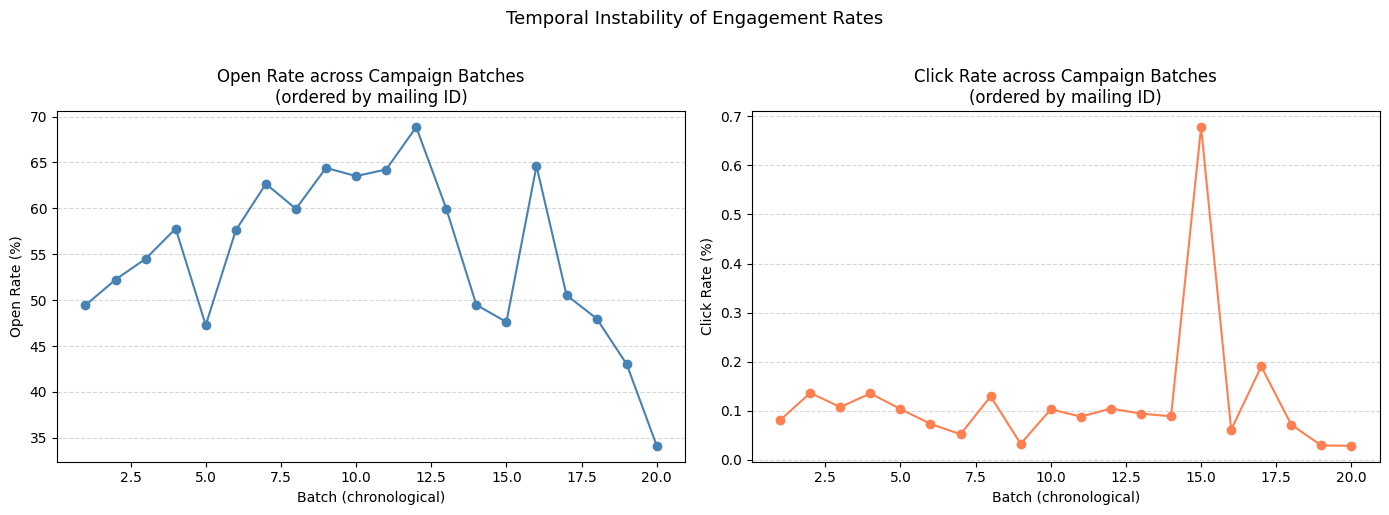


Engagement stability statistics:
  Open rate std across batches:  0.0884
  Click rate std across batches: 0.0014
  Open rate range: 0.341 – 0.689


In [236]:
stability_df = plot_engagement_over_time(df_model)

What it does: it sorts your mailings chronologically by mailing_id, splits them into ~20 batches, and computes the average open rate and click rate within each batch. Then it plots both as line charts over the batches.

Why you need it: your whole individual research question assumes that engagement patterns change over time — that's the reason retraining might help. But right now that's just asserted from literature (He et al., Ruano-Ordás et al.), not shown in your own data. This plot is the empirical evidence: if open/click rates fluctuate noticeably across batches rather than staying flat, it directly motivates "patterns are not consistent, so adaptive retraining is needed" — which was literally the supervisor's note.

Strong evidence of temporal instability.

Open rate: ranges from 33.7% to 67.9% across batches (std = 0.0866), with a clear rise through early-to-mid batches, then a steep decline in the final batches (16→20). That's nearly a 2x swing in open rate depending on when the campaign was sent.
Click rate: mostly stable and low (~0.03–0.13%), but with one dramatic spike at batch 15 (0.67%) — roughly 5-6x the surrounding batches. That's a single anomalous batch, worth a sentence of discussion.

# Open model: split on Mailing IDs

#### Batch Split

create_batches() sorts your unique mailing IDs (low = earlier campaign) and splits them into N equal groups. This is your chronological proxy — the same logic as your baseline model, now extended across multiple steps.

So for i=1: train on batch 0, test on batch 1. For i=2: train on batches 0+1, test on batch 2. And so on — each step the training set grows to include everything seen so far, and you're always testing on the next chronological chunk of campaigns the model hasn't seen.

In [237]:
def create_batches(df, mailing_id_col='mailing_id', n_batches=10):
    sorted_mailings = np.sort(df[mailing_id_col].unique())
    return np.array_split(sorted_mailings, n_batches)

def get_train_test_for_batch(df, batches, batch_idx, window='expanding', window_size=3):
    test_ids = batches[batch_idx]
    if window == 'expanding':
        train_ids = np.concatenate(batches[:batch_idx])
    else:
        start = max(0, batch_idx - window_size)
        train_ids = np.concatenate(batches[start:batch_idx])
    train = df[df['mailing_id'].isin(train_ids)].copy()
    test = df[df['mailing_id'].isin(test_ids)].copy()
    return train, test

Naive Baseline

naive_baseline_predict() implements the exact same baseline already in your notebook — per-user historical mean open rate from training, global mean for unseen users. Now it runs at every batch step, not just once.


In [238]:
def naive_baseline_predict(train, test, target='open', user_col='user_id'):
    user_open_rate = train.groupby(user_col)[target].mean()
    global_mean = train[target].mean()
    return test[user_col].map(user_open_rate).fillna(global_mean).values

def get_feature_cols(df):
    exclude = {'user_id', 'mailing_id', 'open', 'click'}
    return [c for c in df.columns if c not in exclude]

Logistic Regression

train_lr() and predict_lr() handle fitting and prediction. The scaler is always fitted only on training data — no leakage. Handles both open (no weighting) and click (balanced) models

In [239]:
def train_lr(train, feature_cols, target='open'):
    X_train = train[feature_cols].fillna(0)
    y_train = train[target]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    cw = 'balanced' if target == 'click' else None
    model = LogisticRegression(penalty='l2', C=1.0, class_weight=cw, max_iter=1000, random_state=42)
    model.fit(X_train_scaled, y_train)
    return model, scaler

def predict_lr(model, scaler, test, feature_cols):
    X_test = test[feature_cols].fillna(0)
    return model.predict_proba(scaler.transform(X_test))[:, 1]


#### Main Loop 

For each batch step it:

Trains the naive baseline on all prior data
Uses the static LR frozen from batch 0 (never updated)
Retrains the adaptive LR on all data seen so far
Records AUC and MAE for all three on the current test batch

In [240]:
def run_adaptive_evaluation(df, n_batches=10, window='expanding', window_size=3):
    feature_cols = get_feature_cols(df)
    batches = create_batches(df, n_batches=n_batches)

    static_train = df[df['mailing_id'].isin(batches[0])].copy()
    static_fitted = static_train['open'].nunique() == 2
    if static_fitted:
        static_model, static_scaler = train_lr(static_train, feature_cols, 'open')

    results = []
    for i in range(1, len(batches)):
        train, test = get_train_test_for_batch(df, batches, i, window=window, window_size=window_size)
        if len(train) == 0 or len(test) == 0 or test['open'].nunique() < 2:
            continue
        y_test = test['open'].values
        row = {'batch': i, 'n_train_rows': len(train), 'n_test_rows': len(test)}

        naive_preds = naive_baseline_predict(train, test)
        row['baseline_auc'] = roc_auc_score(y_test, naive_preds)
        row['baseline_mae'] = mean_absolute_error(y_test, naive_preds)

        if static_fitted:
            static_preds = predict_lr(static_model, static_scaler, test, feature_cols)
            row['static_lr_auc'] = roc_auc_score(y_test, static_preds)
            row['static_lr_mae'] = mean_absolute_error(y_test, static_preds)

        if train['open'].nunique() == 2:
            adaptive_model, adaptive_scaler = train_lr(train, feature_cols, 'open')
            adaptive_preds = predict_lr(adaptive_model, adaptive_scaler, test, feature_cols)
            row['adaptive_lr_auc'] = roc_auc_score(y_test, adaptive_preds)
            row['adaptive_lr_mae'] = mean_absolute_error(y_test, adaptive_preds)

        results.append(row)
        print(f"Batch {i:2d} | Baseline AUC={row['baseline_auc']:.4f} | Static AUC={row.get('static_lr_auc', float('nan')):.4f} | Adaptive AUC={row.get('adaptive_lr_auc', float('nan')):.4f}")

    return pd.DataFrame(results)

## Evaluation

### Results with expanding window

In [241]:
results_expanding = run_adaptive_evaluation(df_model, n_batches=10, window='expanding')
results_expanding

Batch  1 | Baseline AUC=0.8476 | Static AUC=0.8134 | Adaptive AUC=0.8134
Batch  2 | Baseline AUC=0.8459 | Static AUC=0.8479 | Adaptive AUC=0.8599
Batch  3 | Baseline AUC=0.8454 | Static AUC=0.8555 | Adaptive AUC=0.8584
Batch  4 | Baseline AUC=0.8226 | Static AUC=0.8302 | Adaptive AUC=0.8299
Batch  5 | Baseline AUC=0.8231 | Static AUC=0.8195 | Adaptive AUC=0.7969
Batch  6 | Baseline AUC=0.7637 | Static AUC=0.7523 | Adaptive AUC=0.7644
Batch  7 | Baseline AUC=0.7502 | Static AUC=0.8037 | Adaptive AUC=0.7095
Batch  8 | Baseline AUC=0.7467 | Static AUC=0.7628 | Adaptive AUC=0.7349
Batch  9 | Baseline AUC=0.7371 | Static AUC=0.7573 | Adaptive AUC=0.7589


,batch,n_train_rows,n_test_rows,baseline_auc,baseline_mae,static_lr_auc,static_lr_mae,adaptive_lr_auc,adaptive_lr_mae
0,1,80011,83286,0.847551,0.253074,0.813438,0.315313,0.813438,0.315313
1,2,163297,132598,0.845918,0.265186,0.847887,0.296017,0.859890,0.270852
2,3,295895,116761,0.845364,0.285225,0.855475,0.323978,0.858377,0.280309
3,4,412656,76706,0.822645,0.303833,0.830238,0.358210,0.829944,0.298921
4,5,489362,93583,0.823052,0.302350,0.819488,0.407602,0.796921,0.324682
5,6,582945,68618,0.763704,0.350439,0.752322,0.347062,0.764402,0.361989
6,7,651563,96353,0.750212,0.350715,0.803745,0.365424,0.709529,0.380943
7,8,747916,116730,0.746712,0.368875,0.762765,0.346824,0.734927,0.386758
8,9,864646,146551,0.737133,0.402309,0.757320,0.302086,0.758865,0.392938


Overall pattern: AUC declines steadily across all three models from ~0.85 (batch 1) to ~0.74-0.76 (batch 9). This is consistent with your temporal instability plot — engagement becomes harder to predict in later batches, likely tied to the open rate decline you saw in batches 16-20.

Adaptive vs Static: Adaptive beats static in batches 1, 2, 3, 4, 6 — but loses in batches 5, 7, 8, 9. So it's roughly a wash overall (5/8), with mixed results rather than a clean win. This is actually a nuanced, honest finding — exactly what your supervisor wanted ("sometimes the drop is not consistent").

Notably: batch 1's adaptive and static AUC are identical (0.8134 vs 0.8134) — that's expected, since at batch 1 the adaptive model is trained on the same data as the static model (only batch 0 available).

Adaptive vs Baseline: Baseline wins in batches 1, 2, 3, 6, 8, 9 — adaptive wins in 4, 5, 7. So the naive baseline is actually quite competitive, often outperforming both LR variants.

### Results with sliding window

This retrains on only the last 3 batches instead of all history 

In [242]:
results_sliding = run_adaptive_evaluation(df_model, n_batches=10, window='sliding', window_size=3)
results_sliding

Batch  1 | Baseline AUC=0.8476 | Static AUC=0.8134 | Adaptive AUC=0.8134
Batch  2 | Baseline AUC=0.8459 | Static AUC=0.8479 | Adaptive AUC=0.8599
Batch  3 | Baseline AUC=0.8454 | Static AUC=0.8555 | Adaptive AUC=0.8584
Batch  4 | Baseline AUC=0.8279 | Static AUC=0.8302 | Adaptive AUC=0.8303
Batch  5 | Baseline AUC=0.8366 | Static AUC=0.8195 | Adaptive AUC=0.7945
Batch  6 | Baseline AUC=0.7683 | Static AUC=0.7523 | Adaptive AUC=0.7625
Batch  7 | Baseline AUC=0.7615 | Static AUC=0.8037 | Adaptive AUC=0.7163
Batch  8 | Baseline AUC=0.7492 | Static AUC=0.7628 | Adaptive AUC=0.7400
Batch  9 | Baseline AUC=0.7766 | Static AUC=0.7573 | Adaptive AUC=0.7485


,batch,n_train_rows,n_test_rows,baseline_auc,baseline_mae,static_lr_auc,static_lr_mae,adaptive_lr_auc,adaptive_lr_mae
0,1,80011,83286,0.847551,0.253074,0.813438,0.315313,0.813438,0.315313
1,2,163297,132598,0.845918,0.265186,0.847887,0.296017,0.859890,0.270852
2,3,295895,116761,0.845364,0.285225,0.855475,0.323978,0.858377,0.280309
3,4,332645,76706,0.827891,0.297385,0.830238,0.358210,0.830327,0.309009
4,5,326065,93583,0.836634,0.283085,0.819488,0.407602,0.794506,0.337890
5,6,287050,68618,0.768269,0.344817,0.752322,0.347062,0.762501,0.366643
6,7,238907,96353,0.761534,0.338574,0.803745,0.365424,0.716293,0.387554
7,8,258554,116730,0.749177,0.369723,0.762765,0.346824,0.740018,0.386164
8,9,281701,146551,0.776604,0.375524,0.757320,0.302086,0.748467,0.395161


Takeaway: the two windowing strategies perform very similarly, with no consistent winner — differences are mostly in the 0.5-1.5 point range. Using more historical data (expanding) doesn't reliably help once you're past batch 4, suggesting older data may not be very informative for predicting current behaviour — consistent with concept drift.

Adaptive vs Static (sliding): adaptive wins in 1, 2, 3, 4, 6 — loses in 5, 7, 8, 9. Same pattern as expanding — roughly even.

### Batch size sensitivity
run_batch_size_sensitivity() runs the whole loop for different numbers of batches (5, 10, 15, 20). Directly addresses the supervisor's note about trying different batch sizes.

In [243]:
all_results = {}
for n in [5, 10, 15, 20]:
    print(f"\n=== n_batches = {n} ===")
    all_results[n] = run_adaptive_evaluation(df_model, n_batches=n, window='expanding')


=== n_batches = 5 ===
Batch  1 | Baseline AUC=0.8222 | Static AUC=0.8535 | Adaptive AUC=0.8535
Batch  2 | Baseline AUC=0.8122 | Static AUC=0.8238 | Adaptive AUC=0.8098
Batch  3 | Baseline AUC=0.7523 | Static AUC=0.7858 | Adaptive AUC=0.7423
Batch  4 | Baseline AUC=0.7190 | Static AUC=0.7601 | Adaptive AUC=0.7531

=== n_batches = 10 ===
Batch  1 | Baseline AUC=0.8476 | Static AUC=0.8134 | Adaptive AUC=0.8134
Batch  2 | Baseline AUC=0.8459 | Static AUC=0.8479 | Adaptive AUC=0.8599
Batch  3 | Baseline AUC=0.8454 | Static AUC=0.8555 | Adaptive AUC=0.8584
Batch  4 | Baseline AUC=0.8226 | Static AUC=0.8302 | Adaptive AUC=0.8299
Batch  5 | Baseline AUC=0.8231 | Static AUC=0.8195 | Adaptive AUC=0.7969
Batch  6 | Baseline AUC=0.7637 | Static AUC=0.7523 | Adaptive AUC=0.7644
Batch  7 | Baseline AUC=0.7502 | Static AUC=0.8037 | Adaptive AUC=0.7095
Batch  8 | Baseline AUC=0.7467 | Static AUC=0.7628 | Adaptive AUC=0.7349
Batch  9 | Baseline AUC=0.7371 | Static AUC=0.7573 | Adaptive AUC=0.7589

===

In [244]:
for n, res in all_results.items():
    print(f"\nn_batches={n}")
    print(f"  Mean adaptive AUC: {res['adaptive_lr_auc'].mean():.4f}")
    print(f"  Mean static AUC:   {res['static_lr_auc'].mean():.4f}")
    print(f"  Mean baseline AUC: {res['baseline_auc'].mean():.4f}")
    wins = (res['adaptive_lr_auc'] > res['static_lr_auc']).sum()
    print(f"  Adaptive beats static in {wins}/{len(res)} batches")


n_batches=5
  Mean adaptive AUC: 0.7897
  Mean static AUC:   0.8058
  Mean baseline AUC: 0.7764
  Adaptive beats static in 0/4 batches

n_batches=10
  Mean adaptive AUC: 0.7918
  Mean static AUC:   0.8047
  Mean baseline AUC: 0.7980
  Adaptive beats static in 4/9 batches

n_batches=15
  Mean adaptive AUC: 0.8015
  Mean static AUC:   0.8134
  Mean baseline AUC: 0.8078
  Adaptive beats static in 7/14 batches

n_batches=20
  Mean adaptive AUC: 0.8091
  Mean static AUC:   0.8149
  Mean baseline AUC: 0.8111
  Adaptive beats static in 13/19 batches


Static LR consistently has the highest mean AUC across every batch size — adaptive retraining does not improve mean performance over a model trained once.
Win-rate increases with batch granularity (0% → 44% → 50% → 68%), but this is largely a mechanical artifact: with more, smaller batches, early steps have very similar train sets between static and adaptive (since adaptive hasn't diverged much yet), so they're more likely to tie or be very close. It doesn't represent adaptive becoming "better."
All three models improve slightly as n_batches increases (more batches = smaller test sets per step, and the first batches — which are the highest-AUC, easiest-to-predict ones — make up a larger share of the average).

# Open model: Time split

In [245]:
mailing_dates = pd.read_csv('data/mailing_dates.csv')

df_model_dated = df_model.merge(mailing_dates, on='mailing_id', how='left')
df_model_dated = df_model_dated.dropna(subset=['send_date'])

print(df_model_dated.shape)
print(df_model_dated['mailing_id'].nunique(), "unique mailings")

(711747, 26)
168 unique mailings


#### Batch split 

In [246]:
def create_batches_by_date(df, date_col='send_date', n_batches=10):
    df_sorted = df[[date_col, 'mailing_id']].drop_duplicates().sort_values(date_col)
    sorted_mailings = df_sorted['mailing_id'].values
    return np.array_split(sorted_mailings, n_batches)

In [247]:
def run_adaptive_evaluation_dated(df, n_batches=10, window='expanding', window_size=3):
    batches = create_batches_by_date(df, n_batches=n_batches)
    feature_cols = get_feature_cols(df.drop(columns=['send_date']))
    
    static_train = df[df['mailing_id'].isin(batches[0])].copy()
    static_fitted = static_train['open'].nunique() == 2
    if static_fitted:
        static_model, static_scaler = train_lr(static_train, feature_cols, 'open')

    results = []
    for i in range(1, len(batches)):
        train, test = get_train_test_for_batch(df, batches, i, window=window, window_size=window_size)
        if len(train) == 0 or len(test) == 0 or test['open'].nunique() < 2:
            continue
        y_test = test['open'].values
        row = {'batch': i, 'n_train_rows': len(train), 'n_test_rows': len(test)}

        naive_preds = naive_baseline_predict(train, test)
        row['baseline_auc'] = roc_auc_score(y_test, naive_preds)
        row['baseline_mae'] = mean_absolute_error(y_test, naive_preds)

        if static_fitted:
            static_preds = predict_lr(static_model, static_scaler, test, feature_cols)
            row['static_lr_auc'] = roc_auc_score(y_test, static_preds)
            row['static_lr_mae'] = mean_absolute_error(y_test, static_preds)

        if train['open'].nunique() == 2:
            adaptive_model, adaptive_scaler = train_lr(train, feature_cols, 'open')
            adaptive_preds = predict_lr(adaptive_model, adaptive_scaler, test, feature_cols)
            row['adaptive_lr_auc'] = roc_auc_score(y_test, adaptive_preds)
            row['adaptive_lr_mae'] = mean_absolute_error(y_test, adaptive_preds)

        results.append(row)
        print(f"Batch {i:2d} | Baseline AUC={row['baseline_auc']:.4f} | Static AUC={row.get('static_lr_auc', float('nan')):.4f} | Adaptive AUC={row.get('adaptive_lr_auc', float('nan')):.4f}")

    return pd.DataFrame(results)



### Results with expanding window

In [248]:
results_dated = run_adaptive_evaluation_dated(df_model_dated, n_batches=10, window='expanding')
results_dated

Batch  1 | Baseline AUC=0.8522 | Static AUC=0.8693 | Adaptive AUC=0.8693
Batch  2 | Baseline AUC=0.8807 | Static AUC=0.8674 | Adaptive AUC=0.8525
Batch  3 | Baseline AUC=0.8464 | Static AUC=0.8516 | Adaptive AUC=0.8607
Batch  4 | Baseline AUC=0.8229 | Static AUC=0.8372 | Adaptive AUC=0.8425
Batch  5 | Baseline AUC=0.7982 | Static AUC=0.8218 | Adaptive AUC=0.8313
Batch  6 | Baseline AUC=0.8228 | Static AUC=0.8412 | Adaptive AUC=0.8430
Batch  7 | Baseline AUC=0.7856 | Static AUC=0.8016 | Adaptive AUC=0.7817
Batch  8 | Baseline AUC=0.7294 | Static AUC=0.7792 | Adaptive AUC=0.7692
Batch  9 | Baseline AUC=0.7409 | Static AUC=0.7522 | Adaptive AUC=0.7559


,batch,n_train_rows,n_test_rows,baseline_auc,baseline_mae,static_lr_auc,static_lr_mae,adaptive_lr_auc,adaptive_lr_mae
0,1,63849,55202,0.852187,0.249015,0.869256,0.245785,0.869256,0.245785
1,2,119051,42007,0.880710,0.235207,0.867364,0.259277,0.852476,0.279664
2,3,161058,113089,0.846428,0.270035,0.851625,0.276425,0.860730,0.275246
3,4,274147,73124,0.822942,0.297606,0.837242,0.305595,0.842464,0.286950
4,5,347271,33192,0.798188,0.324942,0.821844,0.350206,0.831305,0.310672
5,6,380463,65721,0.822841,0.305165,0.841205,0.315015,0.843043,0.291019
6,7,446184,75486,0.785633,0.324750,0.801603,0.383309,0.781720,0.362781
7,8,521670,90043,0.729380,0.380663,0.779231,0.355951,0.769180,0.365299
8,9,611713,100034,0.740877,0.393617,0.752181,0.320790,0.755932,0.380699


In [249]:
print(results_dated[['baseline_auc','static_lr_auc','adaptive_lr_auc']].mean())

baseline_auc       0.808798
static_lr_auc      0.824617
adaptive_lr_auc    0.822901
dtype: float64


Key observation: both splits tell the same story — static LR is, on average, at least as good as adaptive retraining, and the win/loss pattern across batches is mixed rather than a consistent trend either way. The date-based split (n=168 mailings, 711,747 rows) reinforces the ID-based split (n=274 mailings, 1,011,197 rows) rather than contradicting it.

Summary across all four analyses (ID-based 10-batch, sliding, batch-size sweep, date-based):

Static LR consistently has marginally higher mean AUC than adaptive retraining
The win/loss split per batch is roughly 50/50, never a clean sweep
Both naive baseline and static/adaptive LR show declining AUC in later batches — temporal drift is real
Restricting to verified send dates (n=168) reproduces the same ordering, confirming the ID-based proxy wasn't distorting the result

# Click model

In [250]:
def run_adaptive_evaluation_click(df, n_batches=10, window='expanding', window_size=3):
    """
    Same walk-forward evaluation as run_adaptive_evaluation, but for the
    click target. Reports AUC-ROC and PR-AUC (average precision) instead
    of MAE, since click is severely imbalanced (0.1% positive rate).
    """
    feature_cols = get_feature_cols(df)
    batches = create_batches(df, n_batches=n_batches)
 
    # Static model: trained once on batch 0
    static_train = df[df['mailing_id'].isin(batches[0])].copy()
    static_fitted = static_train['click'].nunique() == 2
    if static_fitted:
        static_model, static_scaler = train_lr(static_train, feature_cols, 'click')
 
    results = []
    for i in range(1, len(batches)):
        train, test = get_train_test_for_batch(df, batches, i, window=window, window_size=window_size)
        if len(train) == 0 or len(test) == 0 or test['click'].nunique() < 2:
            print(f"Batch {i}: test set has only one class for click, skipping.")
            continue
 
        y_test = test['click'].values
        row = {'batch': i, 'n_train_rows': len(train), 'n_test_rows': len(test)}
 
        # Naive baseline: per-user historical mean CLICK rate
        naive_preds = naive_baseline_predict(train, test, target='click')
        row['baseline_auc'] = roc_auc_score(y_test, naive_preds)
        row['baseline_prauc'] = average_precision_score(y_test, naive_preds)
 
        # Static LR (frozen from batch 0)
        if static_fitted:
            static_preds = predict_lr(static_model, static_scaler, test, feature_cols)
            row['static_lr_auc'] = roc_auc_score(y_test, static_preds)
            row['static_lr_prauc'] = average_precision_score(y_test, static_preds)
 
        # Adaptive LR (retrained on all data seen so far)
        if train['click'].nunique() == 2:
            adaptive_model, adaptive_scaler = train_lr(train, feature_cols, 'click')
            adaptive_preds = predict_lr(adaptive_model, adaptive_scaler, test, feature_cols)
            row['adaptive_lr_auc'] = roc_auc_score(y_test, adaptive_preds)
            row['adaptive_lr_prauc'] = average_precision_score(y_test, adaptive_preds)
        else:
            row['adaptive_lr_auc'] = float('nan')
            row['adaptive_lr_prauc'] = float('nan')
 
        results.append(row)
        print(f"Batch {i:2d} | Baseline AUC={row['baseline_auc']:.4f} PR-AUC={row['baseline_prauc']:.4f} "
              f"| Static AUC={row.get('static_lr_auc', float('nan')):.4f} PR-AUC={row.get('static_lr_prauc', float('nan')):.4f} "
              f"| Adaptive AUC={row.get('adaptive_lr_auc', float('nan')):.4f} PR-AUC={row.get('adaptive_lr_prauc', float('nan')):.4f}")
 
    return pd.DataFrame(results)

### Results with expanding window

In [251]:
results_click = run_adaptive_evaluation_click(df_model, n_batches=10, window='expanding')
results_click

Batch  1 | Baseline AUC=0.7816 PR-AUC=0.1431 | Static AUC=0.8410 PR-AUC=0.2102 | Adaptive AUC=0.8410 PR-AUC=0.2102
Batch  2 | Baseline AUC=0.8546 PR-AUC=0.1309 | Static AUC=0.9375 PR-AUC=0.2103 | Adaptive AUC=0.9491 PR-AUC=0.2302
Batch  3 | Baseline AUC=0.9139 PR-AUC=0.1984 | Static AUC=0.8563 PR-AUC=0.1852 | Adaptive AUC=0.8690 PR-AUC=0.1791
Batch  4 | Baseline AUC=0.8184 PR-AUC=0.1018 | Static AUC=0.9048 PR-AUC=0.0856 | Adaptive AUC=0.8932 PR-AUC=0.0631
Batch  5 | Baseline AUC=0.9013 PR-AUC=0.2165 | Static AUC=0.8625 PR-AUC=0.1820 | Adaptive AUC=0.9812 PR-AUC=0.1679
Batch  6 | Baseline AUC=0.9625 PR-AUC=0.2678 | Static AUC=0.8964 PR-AUC=0.1208 | Adaptive AUC=0.9908 PR-AUC=0.1138
Batch  7 | Baseline AUC=0.7971 PR-AUC=0.0524 | Static AUC=0.9690 PR-AUC=0.3340 | Adaptive AUC=0.9855 PR-AUC=0.3020
Batch  8 | Baseline AUC=0.6836 PR-AUC=0.0824 | Static AUC=0.8148 PR-AUC=0.0543 | Adaptive AUC=0.9323 PR-AUC=0.0685
Batch  9 | Baseline AUC=0.9919 PR-AUC=0.0821 | Static AUC=0.6288 PR-AUC=0.0344 |

,batch,n_train_rows,n_test_rows,baseline_auc,baseline_prauc,static_lr_auc,static_lr_prauc,adaptive_lr_auc,adaptive_lr_prauc
0,1,80011,83286,0.781616,0.143076,0.841029,0.210249,0.841029,0.210249
1,2,163297,132598,0.854644,0.130851,0.937468,0.210293,0.949054,0.230160
2,3,295895,116761,0.913899,0.198419,0.856305,0.185249,0.869037,0.179068
3,4,412656,76706,0.818410,0.101843,0.904822,0.085614,0.893154,0.063060
4,5,489362,93583,0.901320,0.216502,0.862517,0.181993,0.981186,0.167924
5,6,582945,68618,0.962520,0.267757,0.896394,0.120828,0.990793,0.113777
6,7,651563,96353,0.797119,0.052406,0.968965,0.333958,0.985541,0.302042
7,8,747916,116730,0.683636,0.082390,0.814826,0.054294,0.932260,0.068458
8,9,864646,146551,0.991908,0.082078,0.628825,0.034390,0.977610,0.033678


Adaptive vs Static (click):

AUC: adaptive wins in 8/9 batches (loses only batch 3)
PR-AUC: adaptive wins in 5/9 batches (1, 2, 6 win; 3, 4, 7, 8, 9 lose)

So for AUC, adaptive retraining is consistently better for click — a near-complete reversal from the open results, where static won most batches.
But PR-AUC tells a more cautious story. PR-AUC values are volatile and generally low (0.03–0.33) for all three models — consistent with the severe class imbalance (0.1% positive rate). High AUC with low PR-AUC means the models rank well overall but still struggle on precision at realistic thresholds. Batch 9 is striking: adaptive AUC=0.978 but PR-AUC=0.034 — the model ranks positives highly in relative terms, but in absolute terms very few of its top predictions are true clicks.

In [252]:
print(results_click[['baseline_auc','static_lr_auc','adaptive_lr_auc',
                      'baseline_prauc','static_lr_prauc','adaptive_lr_prauc']].mean())

baseline_auc         0.856119
static_lr_auc        0.856795
adaptive_lr_auc      0.935518
baseline_prauc       0.141703
static_lr_prauc      0.157430
adaptive_lr_prauc    0.152046
dtype: float64


AUC: adaptive (0.9355) clearly outperforms both static (0.8568) and baseline (0.8561), which are nearly tied with each other. This is a strong, consistent result — adaptive retraining substantially improves ranking ability for click prediction.
PR-AUC: static (0.1574) is actually slightly higher than adaptive (0.1520), and both are only marginally better than baseline (0.1417). All three are low in absolute terms — expected given 0.1% positive rate.

### Results with sliding window

In [253]:
results_click_sliding = run_adaptive_evaluation_click(df_model, n_batches=10, window='sliding', window_size=3)
results_click_sliding

Batch  1 | Baseline AUC=0.7816 PR-AUC=0.1431 | Static AUC=0.8410 PR-AUC=0.2102 | Adaptive AUC=0.8410 PR-AUC=0.2102
Batch  2 | Baseline AUC=0.8546 PR-AUC=0.1309 | Static AUC=0.9375 PR-AUC=0.2103 | Adaptive AUC=0.9491 PR-AUC=0.2302
Batch  3 | Baseline AUC=0.9139 PR-AUC=0.1984 | Static AUC=0.8563 PR-AUC=0.1852 | Adaptive AUC=0.8690 PR-AUC=0.1791
Batch  4 | Baseline AUC=0.8630 PR-AUC=0.1912 | Static AUC=0.9048 PR-AUC=0.0856 | Adaptive AUC=0.8763 PR-AUC=0.0605
Batch  5 | Baseline AUC=0.8647 PR-AUC=0.1768 | Static AUC=0.8625 PR-AUC=0.1820 | Adaptive AUC=0.9046 PR-AUC=0.2472
Batch  6 | Baseline AUC=0.9290 PR-AUC=0.2698 | Static AUC=0.8964 PR-AUC=0.1208 | Adaptive AUC=0.9732 PR-AUC=0.1637
Batch  7 | Baseline AUC=0.7987 PR-AUC=0.0499 | Static AUC=0.9690 PR-AUC=0.3340 | Adaptive AUC=0.9570 PR-AUC=0.3694
Batch  8 | Baseline AUC=0.6567 PR-AUC=0.0775 | Static AUC=0.8148 PR-AUC=0.0543 | Adaptive AUC=0.9431 PR-AUC=0.0760
Batch  9 | Baseline AUC=0.8240 PR-AUC=0.0774 | Static AUC=0.6288 PR-AUC=0.0344 |

,batch,n_train_rows,n_test_rows,baseline_auc,baseline_prauc,static_lr_auc,static_lr_prauc,adaptive_lr_auc,adaptive_lr_prauc
0,1,80011,83286,0.781616,0.143076,0.841029,0.210249,0.841029,0.210249
1,2,163297,132598,0.854644,0.130851,0.937468,0.210293,0.949054,0.230160
2,3,295895,116761,0.913899,0.198419,0.856305,0.185249,0.869037,0.179068
3,4,332645,76706,0.862996,0.191156,0.904822,0.085614,0.876317,0.060504
4,5,326065,93583,0.864656,0.176822,0.862517,0.181993,0.904556,0.247248
5,6,287050,68618,0.929001,0.269776,0.896394,0.120828,0.973168,0.163694
6,7,238907,96353,0.798700,0.049897,0.968965,0.333958,0.956968,0.369388
7,8,258554,116730,0.656676,0.077501,0.814826,0.054294,0.943052,0.076003
8,9,281701,146551,0.824022,0.077441,0.628825,0.034390,0.982733,0.064872


In [254]:
print(results_click_sliding[['baseline_auc','static_lr_auc','adaptive_lr_auc',
                              'baseline_prauc','static_lr_prauc','adaptive_lr_prauc']].mean())

baseline_auc         0.831801
static_lr_auc        0.856795
adaptive_lr_auc      0.921768
baseline_prauc       0.146104
static_lr_prauc      0.157430
adaptive_lr_prauc    0.177909
dtype: float64


In [255]:
n_beats_auc = (results_click_sliding['adaptive_lr_auc'] > results_click_sliding['static_lr_auc']).sum()
n_beats_prauc = (results_click_sliding['adaptive_lr_prauc'] > results_click_sliding['static_lr_prauc']).sum()
print(f"Adaptive beats static AUC: {n_beats_auc}/9, PR-AUC: {n_beats_prauc}/9")

Adaptive beats static AUC: 6/9, PR-AUC: 6/9


### Batch size sensitivity

In [256]:
all_results_click = {}
for n in [5, 10, 15, 20]:
    print(f"\n=== n_batches = {n} ===")
    all_results_click[n] = run_adaptive_evaluation_click(df_model, n_batches=n, window='expanding')

for n, res in all_results_click.items():
    print(f"\nn_batches={n}")
    print(f"  Mean AUC   - baseline: {res['baseline_auc'].mean():.4f} | static: {res['static_lr_auc'].mean():.4f} | adaptive: {res['adaptive_lr_auc'].mean():.4f}")
    print(f"  Mean PRAUC - baseline: {res['baseline_prauc'].mean():.4f} | static: {res['static_lr_prauc'].mean():.4f} | adaptive: {res['adaptive_lr_prauc'].mean():.4f}")


=== n_batches = 5 ===
Batch  1 | Baseline AUC=0.8261 PR-AUC=0.1156 | Static AUC=0.9317 PR-AUC=0.2239 | Adaptive AUC=0.9317 PR-AUC=0.2239
Batch  2 | Baseline AUC=0.8170 PR-AUC=0.1365 | Static AUC=0.9438 PR-AUC=0.1144 | Adaptive AUC=0.9490 PR-AUC=0.1188
Batch  3 | Baseline AUC=0.8390 PR-AUC=0.0726 | Static AUC=0.9660 PR-AUC=0.2328 | Adaptive AUC=0.9858 PR-AUC=0.2511
Batch  4 | Baseline AUC=0.7288 PR-AUC=0.0704 | Static AUC=0.9114 PR-AUC=0.0308 | Adaptive AUC=0.9386 PR-AUC=0.0437

=== n_batches = 10 ===
Batch  1 | Baseline AUC=0.7816 PR-AUC=0.1431 | Static AUC=0.8410 PR-AUC=0.2102 | Adaptive AUC=0.8410 PR-AUC=0.2102
Batch  2 | Baseline AUC=0.8546 PR-AUC=0.1309 | Static AUC=0.9375 PR-AUC=0.2103 | Adaptive AUC=0.9491 PR-AUC=0.2302
Batch  3 | Baseline AUC=0.9139 PR-AUC=0.1984 | Static AUC=0.8563 PR-AUC=0.1852 | Adaptive AUC=0.8690 PR-AUC=0.1791
Batch  4 | Baseline AUC=0.8184 PR-AUC=0.1018 | Static AUC=0.9048 PR-AUC=0.0856 | Adaptive AUC=0.8932 PR-AUC=0.0631
Batch  5 | Baseline AUC=0.9013 PR

In [257]:
for n, res in all_results_click.items():
    print(f"n_batches={n}")
    print(f"  Mean AUC   - baseline: {res['baseline_auc'].mean():.4f} | static: {res['static_lr_auc'].mean():.4f} | adaptive: {res['adaptive_lr_auc'].mean():.4f}")
    print(f"  Mean PRAUC - baseline: {res['baseline_prauc'].mean():.4f} | static: {res['static_lr_prauc'].mean():.4f} | adaptive: {res['adaptive_lr_prauc'].mean():.4f}")
    print()

n_batches=5
  Mean AUC   - baseline: 0.8027 | static: 0.9382 | adaptive: 0.9513
  Mean PRAUC - baseline: 0.0987 | static: 0.1505 | adaptive: 0.1594

n_batches=10
  Mean AUC   - baseline: 0.8561 | static: 0.8568 | adaptive: 0.9355
  Mean PRAUC - baseline: 0.1417 | static: 0.1574 | adaptive: 0.1520

n_batches=15
  Mean AUC   - baseline: 0.8823 | static: 0.8574 | adaptive: 0.9435
  Mean PRAUC - baseline: 0.1936 | static: 0.2235 | adaptive: 0.1901

n_batches=20
  Mean AUC   - baseline: 0.8821 | static: 0.7000 | adaptive: 0.9291
  Mean PRAUC - baseline: 0.1935 | static: 0.0509 | adaptive: 0.1532



# Summary

#### Functions

In [258]:
def plot_auc_over_batches(results_df, title_suffix='', window_label='Expanding Window', metric='auc'):
    fig, ax = plt.subplots(figsize=(8, 5))
    steps = results_df['batch']

    baseline_col = f'baseline_{metric}'
    static_col = f'static_lr_{metric}'
    adaptive_col = f'adaptive_lr_{metric}'

    ax.plot(steps, results_df[baseline_col], label='Naive Baseline',
            marker='o', linestyle='--', color='grey')
    if static_col in results_df.columns:
        ax.plot(steps, results_df[static_col], label='Static LR (trained once)',
                marker='s', linestyle=':', color='steelblue')
    ax.plot(steps, results_df[adaptive_col], label='Adaptive LR (retrained)',
            marker='^', linestyle='-', color='coral')

    vals = results_df[adaptive_col].values
    for j in range(1, len(vals)):
        if not np.isnan(vals[j]) and not np.isnan(vals[j-1]):
            if metric in ('auc', 'prauc') and vals[j] < vals[j-1] - 0.01:
                ax.annotate('↓', xy=(steps.iloc[j], vals[j]), fontsize=14, color='red', ha='center', va='top')
            elif metric == 'mae' and vals[j] > vals[j-1] + 0.01:
                ax.annotate('↓', xy=(steps.iloc[j], vals[j]), fontsize=14, color='red', ha='center', va='bottom')

    metric_label = {'auc': 'AUC-ROC', 'mae': 'MAE', 'prauc': 'PR-AUC'}[metric]
    ax.set_title(f'{metric_label} over Retraining Steps ({window_label}){title_suffix}', fontsize=12)
    ax.set_xlabel('Batch Step')
    ax.set_ylabel(metric_label)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_batch_size_comparison(all_results, metric='auc', target='open'):
    fig, ax = plt.subplots(figsize=(8, 5))

    batch_sizes = sorted(all_results.keys())
    baseline_col = f'baseline_{metric}'
    static_col = f'static_lr_{metric}'
    adaptive_col = f'adaptive_lr_{metric}'

    baseline_means = [all_results[n][baseline_col].mean() for n in batch_sizes]
    static_means = [all_results[n][static_col].mean() for n in batch_sizes]
    adaptive_means = [all_results[n][adaptive_col].mean() for n in batch_sizes]

    ax.plot(batch_sizes, baseline_means, marker='o', linestyle='--', label='Naive Baseline', color='grey')
    ax.plot(batch_sizes, static_means, marker='s', linestyle=':', label='Static LR', color='steelblue')
    ax.plot(batch_sizes, adaptive_means, marker='^', linestyle='-', label='Adaptive LR', color='coral')

    metric_label = {'auc': 'AUC-ROC', 'prauc': 'PR-AUC'}[metric]
    ax.set_xlabel('Number of Batches')
    ax.set_ylabel(f'Mean {metric_label}')
    ax.set_title(f'Effect of Batch Size on Mean {metric_label} ({target})')
    ax.set_xticks(batch_sizes)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


def print_summary_table(results_df, target='open', metrics=('auc', 'mae')):
    cols = ['batch', 'n_train_rows', 'n_test_rows']
    for m in metrics:
        for model in ['baseline', 'static_lr', 'adaptive_lr']:
            col = f'{model}_{m}'
            if col in results_df.columns:
                cols.append(col)

    summary = results_df[cols].round(4)

    print("=" * 90)
    print(f"ADAPTIVE RETRAINING RESULTS SUMMARY — target = {target}")
    print("=" * 90)
    print(summary.to_string(index=False))
    print("=" * 90)

    print("\nMEAN PERFORMANCE ACROSS ALL BATCHES:")
    for model in ['baseline', 'static_lr', 'adaptive_lr']:
        line = f"  {model:12s} | "
        for m in metrics:
            col = f'{model}_{m}'
            if col in results_df.columns:
                line += f"{m.upper()}: {results_df[col].mean():.4f} ± {results_df[col].std():.4f}  "
        print(line)

    for m in metrics:
        adaptive_col = f'adaptive_lr_{m}'
        static_col = f'static_lr_{m}'
        baseline_col = f'baseline_{m}'
        if adaptive_col in results_df.columns and static_col in results_df.columns:
            valid = results_df[[adaptive_col, static_col]].dropna()
            if m == 'mae':
                n_beats = (valid[adaptive_col] < valid[static_col]).sum()
            else:
                n_beats = (valid[adaptive_col] > valid[static_col]).sum()
            print(f"\nAdaptive LR beats Static LR on {m.upper()} in {n_beats}/{len(valid)} batches")
        if adaptive_col in results_df.columns and baseline_col in results_df.columns:
            valid = results_df[[adaptive_col, baseline_col]].dropna()
            if m == 'mae':
                n_beats = (valid[adaptive_col] < valid[baseline_col]).sum()
            else:
                n_beats = (valid[adaptive_col] > valid[baseline_col]).sum()
            print(f"Adaptive LR beats Naive Baseline on {m.upper()} in {n_beats}/{len(valid)} batches")
    print()

## Plots

### Open

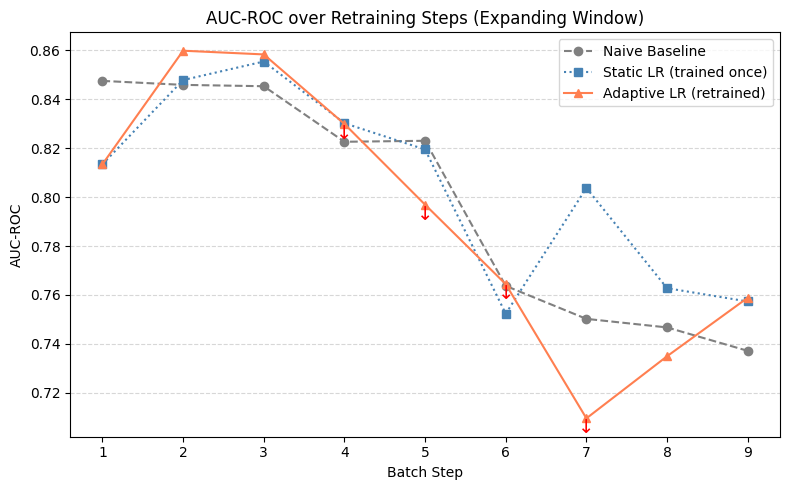

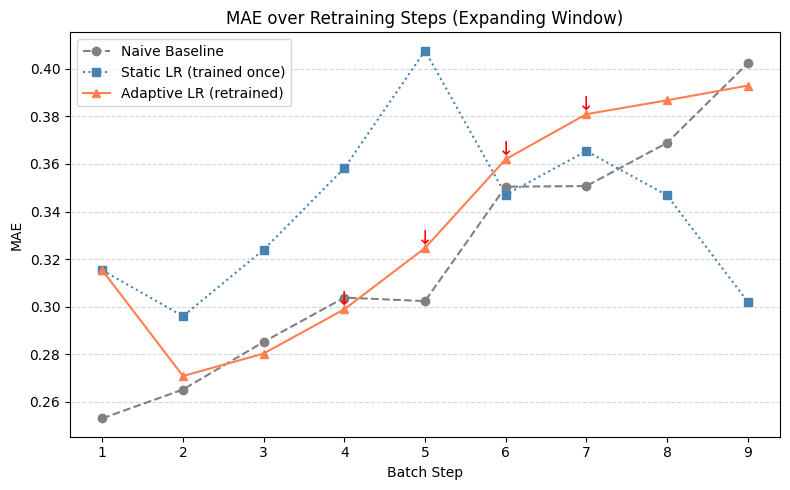

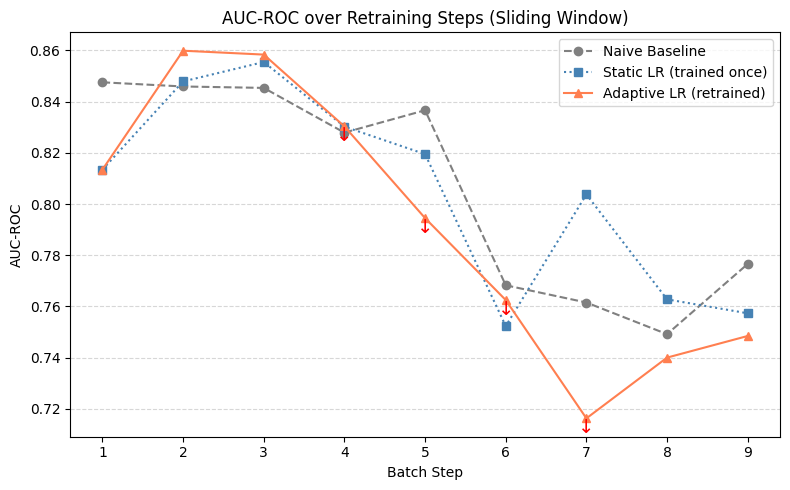

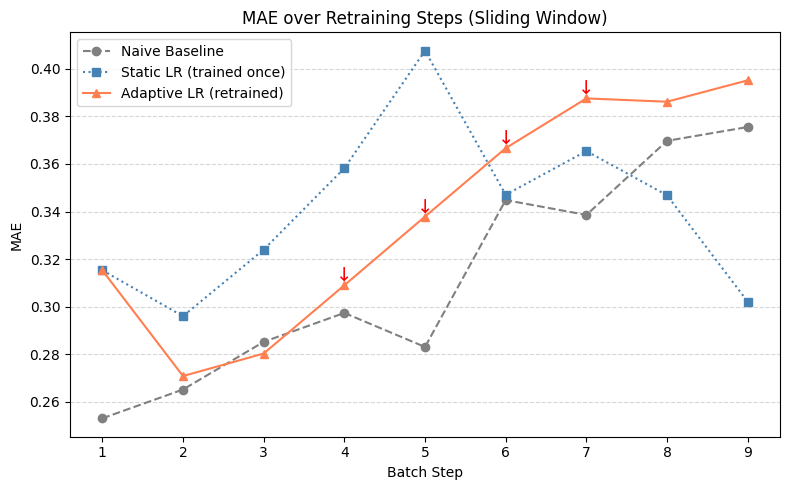

In [259]:
# Open: expanding window AUC and MAE 
plot_auc_over_batches(results_expanding, window_label='Expanding Window', metric='auc')
plot_auc_over_batches(results_expanding, window_label='Expanding Window', metric='mae')

# Open: sliding window AUC and MAE
plot_auc_over_batches(results_sliding, window_label='Sliding Window', metric='auc')
plot_auc_over_batches(results_sliding, window_label='Sliding Window', metric='mae')

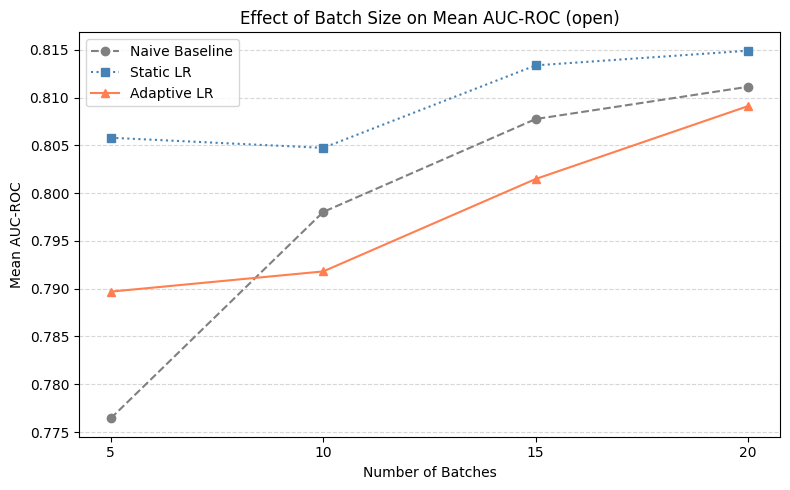

In [260]:
# Open: batch size comparison (AUC)
plot_batch_size_comparison(all_results, metric='auc', target='open')

### Click

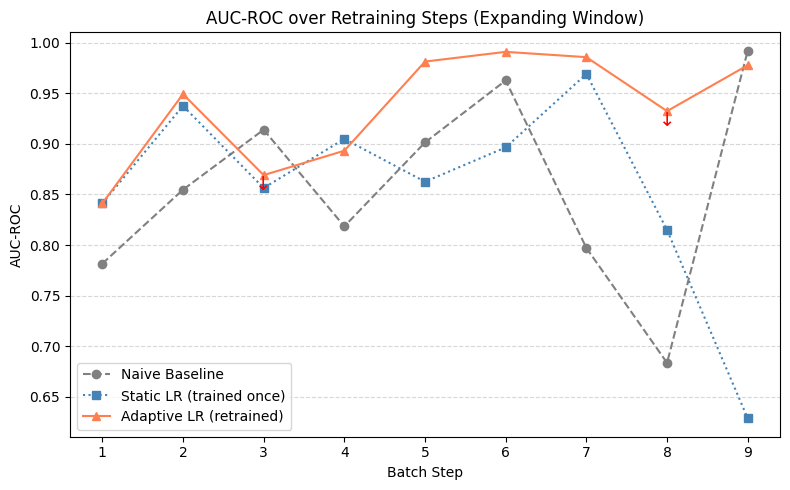

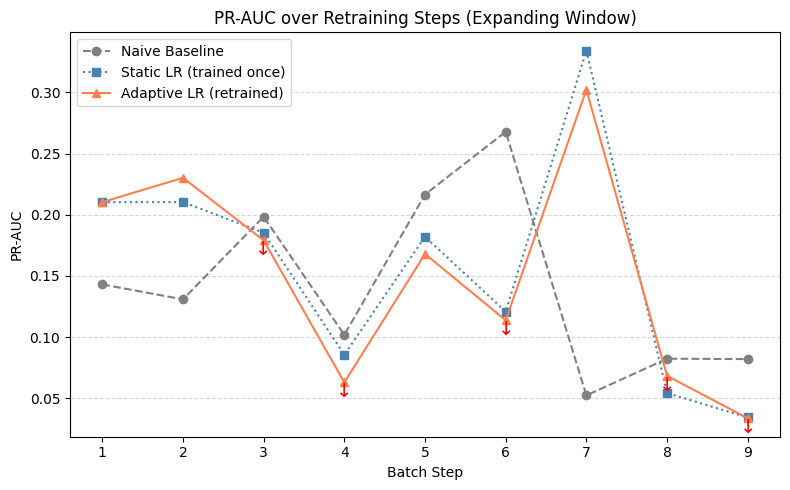

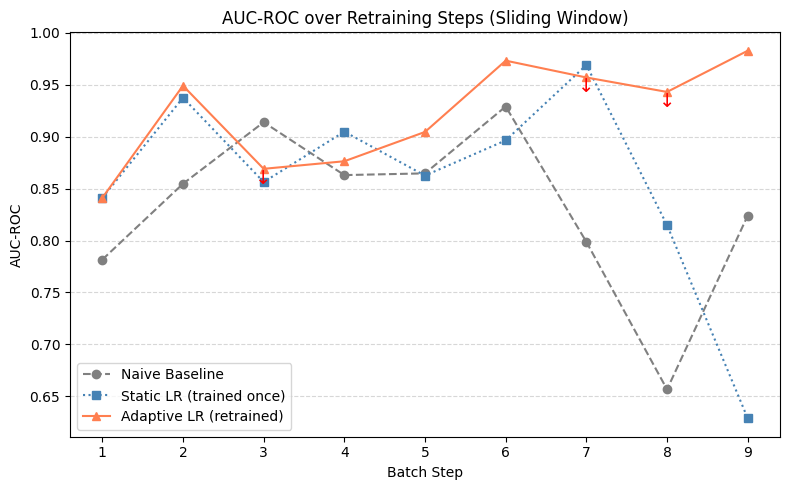

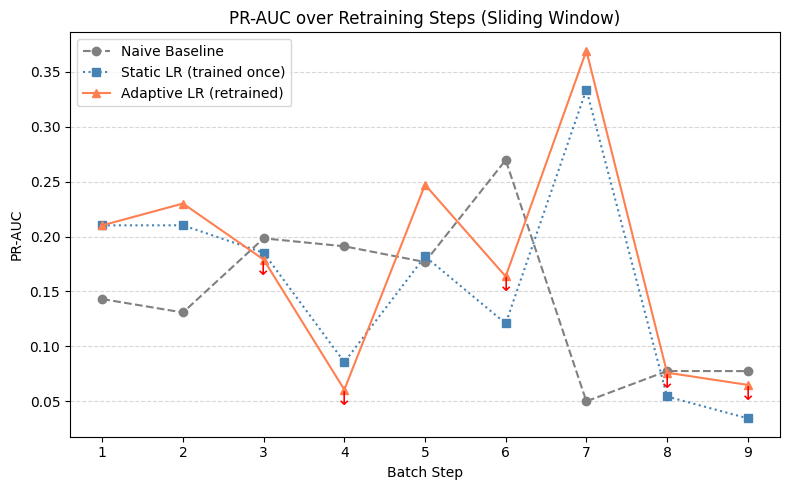

In [261]:
# Click: expanding window AUC and PR-AUC
plot_auc_over_batches(results_click, window_label='Expanding Window', metric='auc')
plot_auc_over_batches(results_click, window_label='Expanding Window', metric='prauc')

# Click: sliding window AUC and PR-AUC
plot_auc_over_batches(results_click_sliding, window_label='Sliding Window', metric='auc')
plot_auc_over_batches(results_click_sliding, window_label='Sliding Window', metric='prauc')

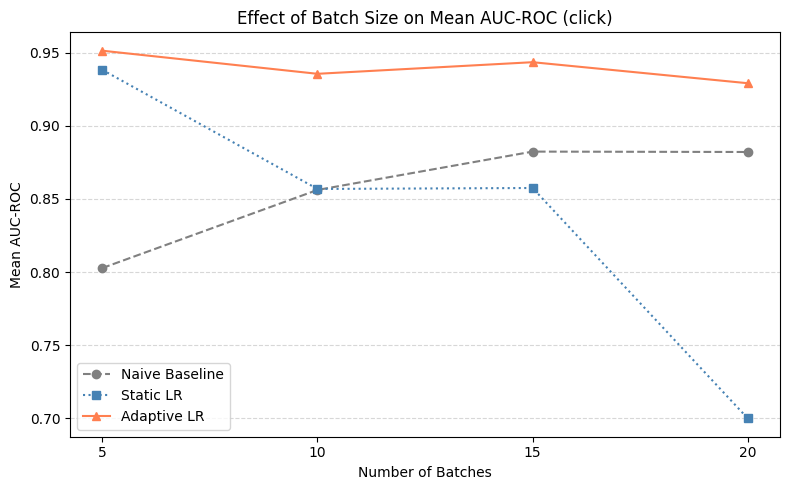

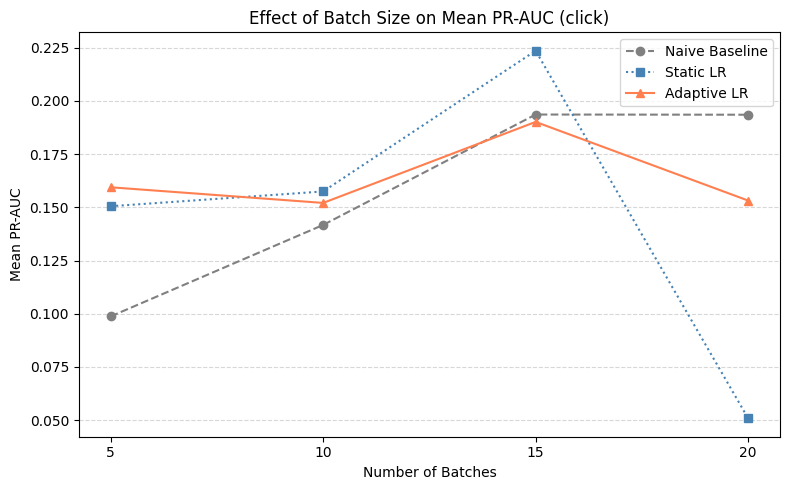

In [262]:
# Click: batch size comparison (AUC and PR-AUC)
plot_batch_size_comparison(all_results_click, metric='auc', target='click')
plot_batch_size_comparison(all_results_click, metric='prauc', target='click')

## Tables

In [263]:
print_summary_table(results_expanding, target='open', metrics=('auc', 'mae'))

ADAPTIVE RETRAINING RESULTS SUMMARY — target = open
 batch  n_train_rows  n_test_rows  baseline_auc  static_lr_auc  adaptive_lr_auc  baseline_mae  static_lr_mae  adaptive_lr_mae
     1         80011        83286        0.8476         0.8134           0.8134        0.2531         0.3153           0.3153
     2        163297       132598        0.8459         0.8479           0.8599        0.2652         0.2960           0.2709
     3        295895       116761        0.8454         0.8555           0.8584        0.2852         0.3240           0.2803
     4        412656        76706        0.8226         0.8302           0.8299        0.3038         0.3582           0.2989
     5        489362        93583        0.8231         0.8195           0.7969        0.3024         0.4076           0.3247
     6        582945        68618        0.7637         0.7523           0.7644        0.3504         0.3471           0.3620
     7        651563        96353        0.7502         0.8037    

In [264]:
print_summary_table(results_click, target='click', metrics=('auc', 'prauc'))

ADAPTIVE RETRAINING RESULTS SUMMARY — target = click
 batch  n_train_rows  n_test_rows  baseline_auc  static_lr_auc  adaptive_lr_auc  baseline_prauc  static_lr_prauc  adaptive_lr_prauc
     1         80011        83286        0.7816         0.8410           0.8410          0.1431           0.2102             0.2102
     2        163297       132598        0.8546         0.9375           0.9491          0.1309           0.2103             0.2302
     3        295895       116761        0.9139         0.8563           0.8690          0.1984           0.1852             0.1791
     4        412656        76706        0.8184         0.9048           0.8932          0.1018           0.0856             0.0631
     5        489362        93583        0.9013         0.8625           0.9812          0.2165           0.1820             0.1679
     6        582945        68618        0.9625         0.8964           0.9908          0.2678           0.1208             0.1138
     7        651563   

### Test

In [265]:
# Open
diff_open = (results_expanding['adaptive_lr_auc'] - results_expanding['static_lr_auc']).dropna()
stat, p = wilcoxon(diff_open)
print(f"Open AUC — Wilcoxon p-value: {p:.4f}")

# Click
diff_click = (results_click['adaptive_lr_auc'] - results_click['static_lr_auc']).dropna()
stat, p = wilcoxon(diff_click)
print(f"Click AUC — Wilcoxon p-value: {p:.4f}")

Open AUC — Wilcoxon p-value: 0.6406
Click AUC — Wilcoxon p-value: 0.0234


Open (p = 0.6406): not significant — consistent with "essentially equivalent" performance between adaptive and static LR. The 4/9 win split and small mean difference (0.013) are consistent with random fluctuation rather than a real effect.

Click (p = 0.0234): significant at the conventional 0.05 threshold — the AUC improvement from adaptive retraining for click is unlikely to be due to chance, despite the small sample (n=9). This gives statistical backing to your strongest finding.